# Landmark Detection Project
### Landmark Image Classification with a Vision Transformer Built from Scratch

## Section 1 - Imports and Reproducibility

In [1]:
from importlib import metadata
import subprocess
import sys

required_packages = [
    "requests",
    "pillow",
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "tensorflow",
    "ipywidgets",
]

missing_packages = []
for package_name in required_packages:
    try:
        metadata.version(package_name)
    except metadata.PackageNotFoundError:
        missing_packages.append(package_name)

if missing_packages:
    print("Installing missing packages:", missing_packages)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing_packages)
else:
    print("All required packages are available.")

All required packages are available.


In [2]:
import os
import random
import hashlib
import time
from pathlib import Path

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style("whitegrid")
print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.22.0-rc0
GPU devices: []


## Section 2 - Dataset Download and Verification

In [5]:
DATASET_ROOT = Path("landmark_dataset_v2_clean")
METADATA_PATH = DATASET_ROOT / "metadata.csv"
IMAGES_PER_CLASS = 100
DOWNLOAD_SIZE = 480
MAX_RETRIES = 6
API_DELAY_SECONDS = 3.0
IMAGE_DELAY_SECONDS = 0.12

LANDMARK_CATEGORIES = {
    "Eiffel_Tower": "Category:Eiffel Tower",
    "Taj_Mahal": "Category:Taj Mahal",
    "Statue_of_Liberty": "Category:Statue of Liberty",
    "Colosseum": "Category:Colosseum",
    "Sydney_Opera_House": "Category:Sydney Opera House",
}


API_URL = "https://commons.wikimedia.org/w/api.php"
HEADERS = {"User-Agent": "EducationalLandmarkViT/1.0 (notebook project)"}

def request_with_backoff(url, *, params=None, timeout=45):
    for attempt in range(MAX_RETRIES):
        response = requests.get(url, params=params, headers=HEADERS, timeout=timeout)
        if response.status_code != 429:
            response.raise_for_status()
            return response
        retry_after = response.headers.get("Retry-After")
        wait_seconds = float(retry_after) if retry_after and retry_after.isdigit() else min(60, 5 * (2 ** attempt))
        print(f"Rate limited by Wikimedia. Waiting {wait_seconds:.0f} seconds before retry {attempt + 1}/{MAX_RETRIES}...")
        time.sleep(wait_seconds)
    raise RuntimeError("Wikimedia remained rate limited after all retries. Wait a few minutes, then rerun this cell; existing images will be reused.")

def get_commons_category_images(category_name, limit=160):
    params = {
        "action": "query",
        "generator": "categorymembers",
        "gcmtitle": category_name,
        "gcmnamespace": 6,
        "gcmtype": "file",
        "gcmlimit": min(limit, 200),
        "prop": "imageinfo",
        "iiprop": "url|mime",
        "iiurlwidth": DOWNLOAD_SIZE,
        "format": "json",
    }
    records = []
    seen_titles = set()
    while len(records) < limit:
        response = request_with_backoff(API_URL, params=params, timeout=45)
        response_data = response.json()
        pages = response_data.get("query", {}).get("pages", {})
        for page in pages.values():
            image_info = page.get("imageinfo", [{}])[0]
            mime = image_info.get("mime", "")
            title = page.get("title", "Unknown")
            if mime not in {"image/jpeg", "image/png"} or title in seen_titles:
                continue
            download_url = image_info.get("thumburl") or image_info.get("url")
            if not download_url:
                continue
            seen_titles.add(title)
            records.append({
                "title": title,
                "download_url": download_url,
                "original_url": image_info.get("url", ""),
                "description_url": image_info.get("descriptionurl", ""),
            })
            if len(records) >= limit:
                break
        continuation = response_data.get("continue")
        if len(records) >= limit or not continuation:
            break
        params.update(continuation)
        time.sleep(1.0)
    return records[:limit]

def download_landmark_dataset():
    DATASET_ROOT.mkdir(exist_ok=True)
    metadata_rows = []
    known_hashes = set()

    for class_name, category_name in LANDMARK_CATEGORIES.items():
        class_dir = DATASET_ROOT / class_name
        class_dir.mkdir(parents=True, exist_ok=True)
        existing_images = sorted(class_dir.glob("*.jpg"))[:IMAGES_PER_CLASS]
        for image_path in existing_images:
            try:
                with Image.open(image_path) as image:
                    image.verify()
                existing_bytes = image_path.read_bytes()
                known_hashes.add(hashlib.sha256(existing_bytes).hexdigest())
                metadata_rows.append({"class_name": class_name, "title": image_path.stem, "local_path": str(image_path), "description_url": "", "original_url": ""})
            except Exception:
                image_path.unlink(missing_ok=True)

        valid_count = sum(1 for row in metadata_rows if row["class_name"] == class_name)
        print(f"{class_name}: found {valid_count} existing valid images")
        if valid_count >= IMAGES_PER_CLASS:
            print(f"{class_name}: class already complete")
            continue

        time.sleep(API_DELAY_SECONDS)
        search_results = get_commons_category_images(category_name, limit=160)

        for record in search_results:
            if valid_count >= IMAGES_PER_CLASS:
                break
            try:
                image_response = request_with_backoff(record["download_url"], timeout=45)
                image_bytes = image_response.content
                file_hash = hashlib.sha256(image_bytes).hexdigest()
                if file_hash in known_hashes:
                    continue
                temporary_path = class_dir / "temporary_image"
                temporary_path.write_bytes(image_bytes)
                with Image.open(temporary_path) as image:
                    image = image.convert("RGB")
                    if min(image.size) < 160:
                        temporary_path.unlink(missing_ok=True)
                        continue
                    final_path = class_dir / f"{class_name}_{valid_count:03d}.jpg"
                    image.save(final_path, format="JPEG", quality=90)
                temporary_path.unlink(missing_ok=True)
                known_hashes.add(file_hash)
                metadata_rows.append({
                    "class_name": class_name,
                    "title": record["title"],
                    "local_path": str(final_path),
                    "description_url": record["description_url"],
                    "original_url": record["original_url"],
                })
                valid_count += 1
                time.sleep(IMAGE_DELAY_SECONDS)
            except Exception as error:
                temporary_path = class_dir / "temporary_image"
                temporary_path.unlink(missing_ok=True)

        print(f"{class_name}: now has {valid_count} valid images")
        if valid_count < 80:
            raise RuntimeError(f"Only {valid_count} valid images were downloaded for {class_name}; at least 80 are required.")

    metadata_df = pd.DataFrame(metadata_rows)
    metadata_df.to_csv(METADATA_PATH, index=False)
    return metadata_df

metadata_df = download_landmark_dataset()
print("Dataset shape:", metadata_df.shape)
metadata_df.head()

Eiffel_Tower: found 100 existing valid images
Eiffel_Tower: class already complete
Taj_Mahal: found 100 existing valid images
Taj_Mahal: class already complete
Statue_of_Liberty: found 13 existing valid images
Statue_of_Liberty: now has 100 valid images
Colosseum: found 0 existing valid images
Colosseum: now has 100 valid images
Sydney_Opera_House: found 0 existing valid images
Sydney_Opera_House: now has 100 valid images
Dataset shape: (500, 5)


,class_name,title,local_path,description_url,original_url
0,Eiffel_Tower,Eiffel_Tower_000,landmark_dataset_v2_clean\Eiffel_Tower\Eiffel_...,,
1,Eiffel_Tower,Eiffel_Tower_001,landmark_dataset_v2_clean\Eiffel_Tower\Eiffel_...,,
2,Eiffel_Tower,Eiffel_Tower_002,landmark_dataset_v2_clean\Eiffel_Tower\Eiffel_...,,
3,Eiffel_Tower,Eiffel_Tower_003,landmark_dataset_v2_clean\Eiffel_Tower\Eiffel_...,,
4,Eiffel_Tower,Eiffel_Tower_004,landmark_dataset_v2_clean\Eiffel_Tower\Eiffel_...,,


In [6]:
metadata_df["path_exists"] = metadata_df["local_path"].map(lambda path: Path(path).exists())
assert metadata_df["path_exists"].all(), "At least one metadata path does not exist."
assert set(metadata_df["class_name"].unique()) == set(LANDMARK_CATEGORIES), "The downloaded class set is incomplete."

class_counts = metadata_df["class_name"].value_counts().sort_index()
print("Images per class:")
print(class_counts)
print("Total images:", len(metadata_df))
print("Duplicate local paths:", metadata_df["local_path"].duplicated().sum())

Images per class:
class_name
Colosseum             100
Eiffel_Tower          100
Statue_of_Liberty     100
Sydney_Opera_House    100
Taj_Mahal             100
Name: count, dtype: int64
Total images: 500
Duplicate local paths: 0


## Section 3 - Exploratory Data Analysis

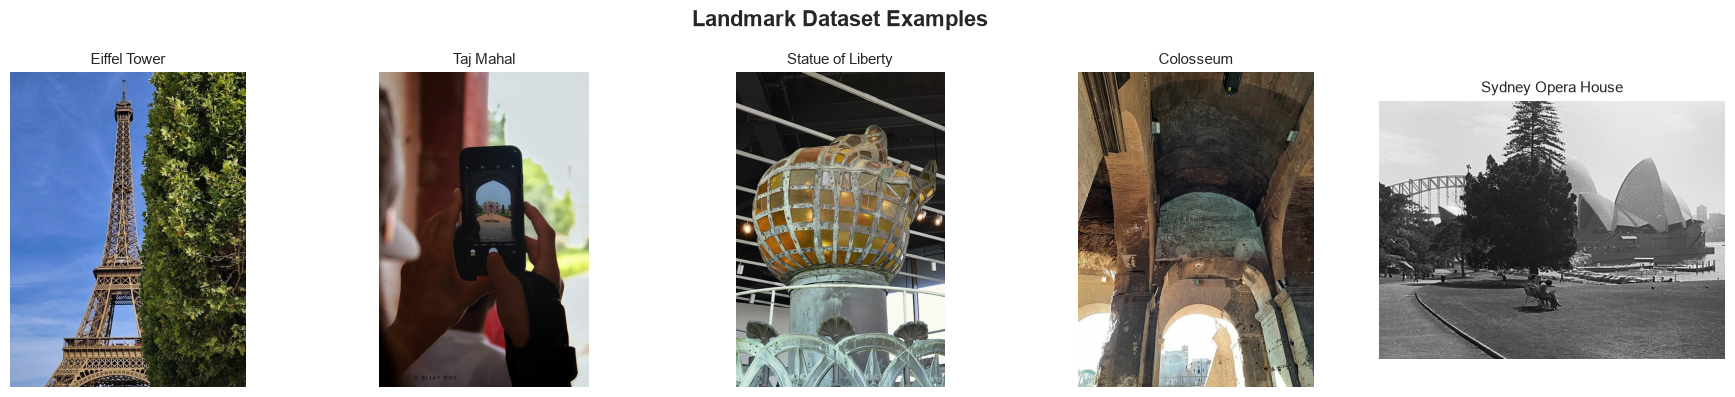

In [7]:
figure, axes = plt.subplots(1, len(LANDMARK_CATEGORIES), figsize=(18, 4))
for axis, class_name in zip(axes, LANDMARK_CATEGORIES):
    sample_path = metadata_df.loc[metadata_df["class_name"] == class_name, "local_path"].iloc[0]
    with Image.open(sample_path) as sample_image:
        axis.imshow(sample_image)
    axis.set_title(class_name.replace("_", " "), fontsize=11)
    axis.axis("off")
plt.suptitle("Landmark Dataset Examples", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

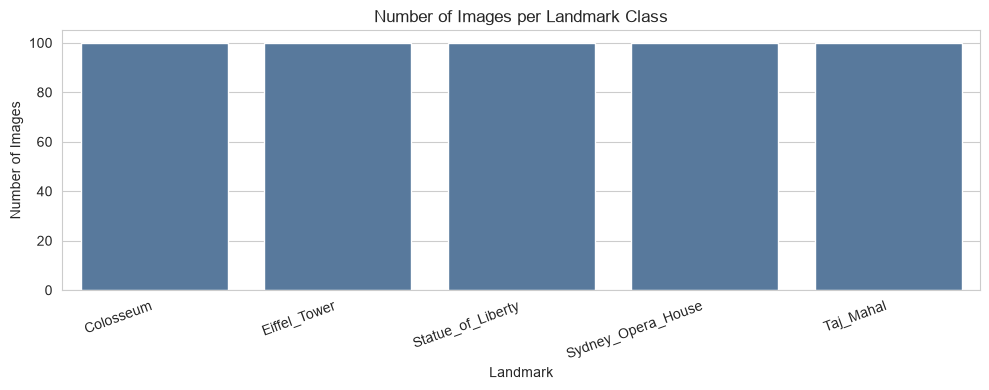

In [8]:
plt.figure(figsize=(10, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, color="#4C78A8")
plt.title("Number of Images per Landmark Class")
plt.xlabel("Landmark")
plt.ylabel("Number of Images")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Section 4 - Stratified Data Splitting and Input Pipeline

In [9]:
CLASS_NAMES = sorted(metadata_df["class_name"].unique().tolist())
CLASS_TO_INDEX = {name: index for index, name in enumerate(CLASS_NAMES)}
metadata_df["label"] = metadata_df["class_name"].map(CLASS_TO_INDEX)

train_df, temporary_df = train_test_split(
    metadata_df,
    test_size=0.30,
    random_state=SEED,
    stratify=metadata_df["label"],
)

validation_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temporary_df["label"],
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Class order:", CLASS_NAMES)
print("Training images:", len(train_df))
print("Validation images:", len(validation_df))
print("Test images:", len(test_df))

Class order: ['Colosseum', 'Eiffel_Tower', 'Statue_of_Liberty', 'Sydney_Opera_House', 'Taj_Mahal']
Training images: 350
Validation images: 75
Test images: 75


In [10]:
IMAGE_SIZE = 160
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

def load_image(image_path, label):
    image_bytes = tf.io.read_file(image_path)
    image = tf.io.decode_jpeg(image_bytes, channels=3)
    image = tf.image.resize_with_pad(image, IMAGE_SIZE, IMAGE_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def create_dataset(frame, training=False):
    dataset = tf.data.Dataset.from_tensor_slices((frame["local_path"].values, frame["label"].values))
    if training:
        dataset = dataset.shuffle(len(frame), seed=SEED, reshuffle_each_iteration=True)
    dataset = dataset.map(load_image, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)
    return dataset

train_dataset = create_dataset(train_df, training=True)
validation_dataset = create_dataset(validation_df)
test_dataset = create_dataset(test_df)

sample_images, sample_labels = next(iter(train_dataset))
print("Training batch image shape:", sample_images.shape)
print("Training batch label shape:", sample_labels.shape)

Training batch image shape: (16, 160, 160, 3)
Training batch label shape: (16,)


## Section 5 - Vision Transformer Architecture

In [11]:
PATCH_SIZE = 16
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2
D_MODEL = 128
NUM_HEADS = 8
FF_DIM = 256
NUM_BLOCKS = 4
DROPOUT_RATE = 0.20
NUM_CLASSES = len(CLASS_NAMES)

class PatchExtractor(tf.keras.layers.Layer):
    def __init__(self, patch_size, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        batch_size = tf.shape(images)[0]
        patch_dimension = self.patch_size * self.patch_size * 3
        return tf.reshape(patches, [batch_size, -1, patch_dimension])

class PatchEncoder(tf.keras.layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection = tf.keras.layers.Dense(projection_dim)
        self.position_embedding = tf.keras.layers.Embedding(input_dim=num_patches, output_dim=projection_dim)

    def call(self, patches):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        return self.projection(patches) + self.position_embedding(positions)

def transformer_encoder_block(inputs, projection_dim, num_heads, ff_dim, dropout_rate):
    normalized_1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)(inputs)
    attention_output = tf.keras.layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=projection_dim // num_heads,
        dropout=dropout_rate,
    )(normalized_1, normalized_1)
    residual_1 = tf.keras.layers.Add()([inputs, attention_output])
    normalized_2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)(residual_1)
    feed_forward = tf.keras.layers.Dense(ff_dim, activation=tf.nn.gelu)(normalized_2)
    feed_forward = tf.keras.layers.Dropout(dropout_rate)(feed_forward)
    feed_forward = tf.keras.layers.Dense(projection_dim)(feed_forward)
    feed_forward = tf.keras.layers.Dropout(dropout_rate)(feed_forward)
    return tf.keras.layers.Add()([residual_1, feed_forward])

def build_vision_transformer():
    inputs = tf.keras.layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3), name="landmark_image")
    augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal", seed=SEED),
        tf.keras.layers.RandomTranslation(0.08, 0.08, seed=SEED),
        tf.keras.layers.RandomRotation(0.04, seed=SEED),
        tf.keras.layers.RandomZoom(0.15, seed=SEED),
        tf.keras.layers.RandomContrast(0.15, seed=SEED),
    ], name="augmentation")
    x = augmentation(inputs)
    x = PatchExtractor(PATCH_SIZE, name="patch_extractor")(x)
    x = PatchEncoder(NUM_PATCHES, D_MODEL, name="patch_encoder")(x)
    for _ in range(NUM_BLOCKS):
        x = transformer_encoder_block(x, D_MODEL, NUM_HEADS, FF_DIM, DROPOUT_RATE)
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(256, activation=tf.nn.gelu)(x)
    x = tf.keras.layers.Dropout(DROPOUT_RATE)(x)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax", name="landmark_probabilities")(x)
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="LandmarkVisionTransformer")
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=5e-4, weight_decay=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

landmark_transformer = build_vision_transformer()
landmark_transformer.summary()
print("Number of image patches:", NUM_PATCHES)

Model: "LandmarkVisionTransformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ landmark_image (InputLayer)   │ (None, 160, 160, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ augmentation (Sequential)     │ (None, 160, 160, 3)       │               0 │ landmark_image[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ patch_extractor               │ (None, None, 768)         │               0 │ augmentation[0][0]         │
│ (PatchExtractor)              │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ patch_encoder (PatchEncoder)  │ (None, 100, 128)          │         111,232 │ patch_extractor[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization           │ (None, 100, 128)          │             256 │ patch_encoder[0][0]        │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention          │ (None, 100, 128)          │          66,048 │ layer_normalization[0][0], │
│ (MultiHeadAttention)          │                           │                 │ layer_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 100, 128)          │               0 │ patch_encoder[0][0],       │
│                               │                           │                 │ multi_head_attention[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_1         │ (None, 100, 128)          │             256 │ add[0][0]                  │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 100, 256)          │          33,024 │ layer_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 100, 256)          │               0 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 100, 128)          │          32,896 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 100, 128)          │               0 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_1 (Add)                   │ (None, 100, 128)          │               0 │ add[0][0], dropout_2[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_2         │ (None, 100, 128)          │             256 │ add_1[0][0]                │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 675,717 (2.58 MB)

 Trainable params: 675,717 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

Number of image patches: 100


## Section 6 - Model Training

In [12]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
)

reduce_learning_rate = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
)

history = landmark_transformer.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=60,
    callbacks=[early_stopping, reduce_learning_rate],
    verbose=1,
)

Epoch 1/60


C:\Users\harsh\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 336ms/step - accuracy: 0.2371 - loss: 1.7657 - val_accuracy: 0.3733 - val_loss: 1.5495 - learning_rate: 5.0000e-04
Epoch 2/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.2914 - loss: 1.5841 - val_accuracy: 0.2667 - val_loss: 1.4927 - learning_rate: 5.0000e-04
Epoch 3/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.3743 - loss: 1.4881 - val_accuracy: 0.4533 - val_loss: 1.3350 - learning_rate: 5.0000e-04
Epoch 4/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.4629 - loss: 1.3073 - val_accuracy: 0.4533 - val_loss: 1.5800 - learning_rate: 5.0000e-04
Epoch 5/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.4286 - loss: 1.3649 - val_accuracy: 0.4133 - val_loss: 1.2848 - learning_rate: 5.0000e-04
Epoch 6/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.5429 - loss: 1.2073 - val_accuracy: 0.4400 - val_loss: 1.2906 - learning_rate: 5.0000e-04
Epoch 7/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.5029 - loss: 1

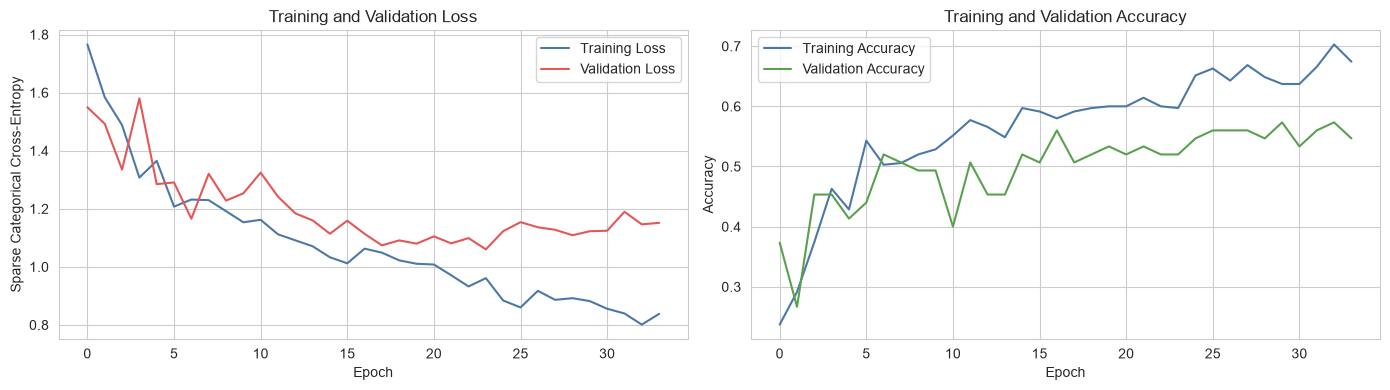

In [13]:
figure, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history["loss"], label="Training Loss", color="#4C78A8")
axes[0].plot(history.history["val_loss"], label="Validation Loss", color="#E45756")
axes[0].set_title("Training and Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Sparse Categorical Cross-Entropy")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Training Accuracy", color="#4C78A8")
axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy", color="#59A14F")
axes[1].set_title("Training and Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## Section 7 - Test Evaluation

In [14]:
def predict_dataset_with_tta(dataset):
    probability_batches = []
    for image_batch, _ in dataset:
        original_probabilities = landmark_transformer(image_batch, training=False).numpy()
        flipped_images = tf.image.flip_left_right(image_batch)
        flipped_probabilities = landmark_transformer(flipped_images, training=False).numpy()
        probability_batches.append((original_probabilities + flipped_probabilities) / 2.0)
    return np.concatenate(probability_batches, axis=0)

test_probabilities = predict_dataset_with_tta(test_dataset)
test_predictions = np.argmax(test_probabilities, axis=1)
test_targets = test_df["label"].to_numpy()

test_accuracy = accuracy_score(test_targets, test_predictions)
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    test_targets,
    test_predictions,
    average="macro",
    zero_division=0,
)

print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Macro Precision: {test_precision:.4f}")
print(f"Macro Recall:    {test_recall:.4f}")
print(f"Macro F1-score:  {test_f1:.4f}")

Test Accuracy:  0.4667
Macro Precision: 0.4657
Macro Recall:    0.4667
Macro F1-score:  0.4546


                    precision    recall  f1-score   support

         Colosseum       0.56      0.33      0.42        15
      Eiffel Tower       0.50      0.47      0.48        15
 Statue of Liberty       0.25      0.20      0.22        15
Sydney Opera House       0.59      0.67      0.62        15
         Taj Mahal       0.43      0.67      0.53        15

          accuracy                           0.47        75
         macro avg       0.47      0.47      0.45        75
      weighted avg       0.47      0.47      0.45        75



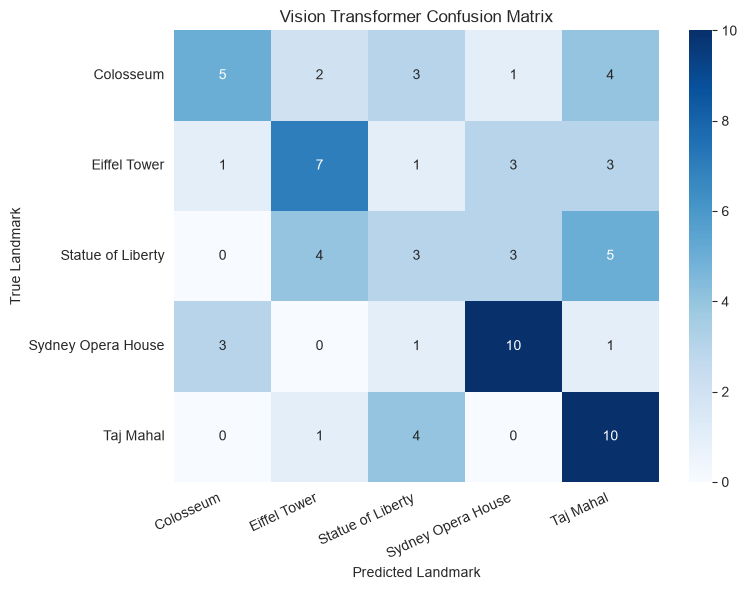

In [15]:
report = classification_report(
    test_targets,
    test_predictions,
    target_names=[name.replace("_", " ") for name in CLASS_NAMES],
    zero_division=0,
)
print(report)

matrix = confusion_matrix(test_targets, test_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[name.replace("_", " ") for name in CLASS_NAMES],
    yticklabels=[name.replace("_", " ") for name in CLASS_NAMES],
)
plt.title("Vision Transformer Confusion Matrix")
plt.xlabel("Predicted Landmark")
plt.ylabel("True Landmark")
plt.xticks(rotation=25, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Section 8 - Prediction Visualization

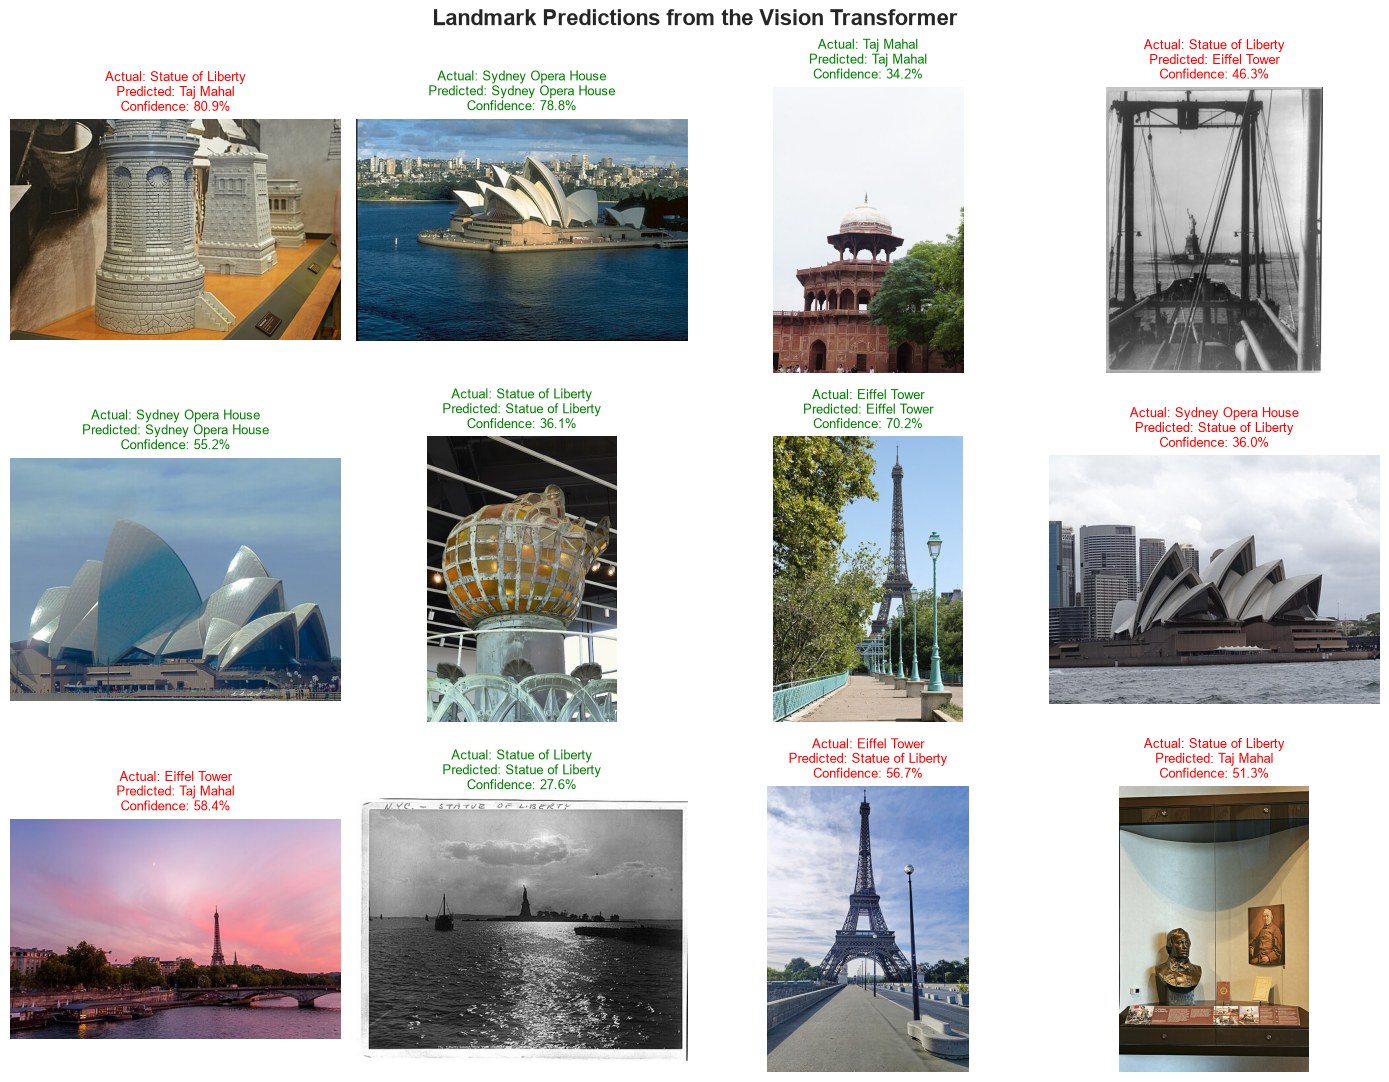

In [16]:
example_count = min(12, len(test_df))
example_indices = np.linspace(0, len(test_df) - 1, example_count, dtype=int)
figure, axes = plt.subplots(3, 4, figsize=(14, 11))

for axis, test_index in zip(axes.flatten(), example_indices):
    image_path = test_df.loc[test_index, "local_path"]
    actual_index = int(test_targets[test_index])
    predicted_index = int(test_predictions[test_index])
    confidence = float(test_probabilities[test_index, predicted_index])
    with Image.open(image_path) as image:
        axis.imshow(image)
    title_color = "green" if actual_index == predicted_index else "red"
    axis.set_title(
        f"Actual: {CLASS_NAMES[actual_index].replace('_', ' ')}\nPredicted: {CLASS_NAMES[predicted_index].replace('_', ' ')}\nConfidence: {confidence:.1%}",
        color=title_color,
        fontsize=9,
    )
    axis.axis("off")

for axis in axes.flatten()[example_count:]:
    axis.axis("off")

plt.suptitle("Landmark Predictions from the Vision Transformer", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## Section 9 - Live Landmark Prediction

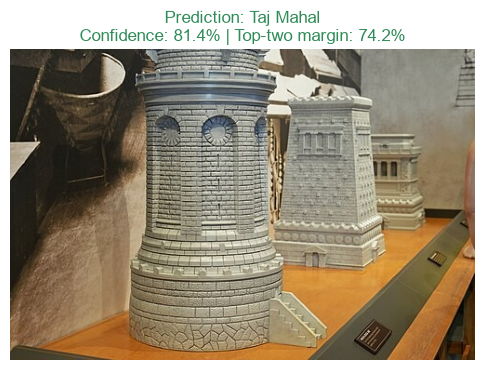

Result: Taj Mahal
Confidence: 81.39%
Top-two margin: 74.18%
Supported landmark accepted: True


In [17]:
MIN_LANDMARK_CONFIDENCE = 0.60
MIN_TOP2_MARGIN = 0.15
REJECTION_LABEL = "Not a supported landmark"

def predict_landmark(image_path, display_image=True):
    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")
    with Image.open(image_path) as image:
        rgb_image = image.convert("RGB")
        original_array = np.asarray(rgb_image, dtype=np.float32)
        image_array = tf.image.resize_with_pad(original_array, IMAGE_SIZE, IMAGE_SIZE).numpy() / 255.0
    original_view = image_array[np.newaxis, ...]
    flipped_view = tf.image.flip_left_right(original_view).numpy()
    original_probabilities = landmark_transformer.predict(original_view, verbose=0)[0]
    flipped_probabilities = landmark_transformer.predict(flipped_view, verbose=0)[0]
    probabilities = (original_probabilities + flipped_probabilities) / 2.0
    predicted_index = int(np.argmax(probabilities))
    confidence = float(probabilities[predicted_index])
    sorted_probabilities = np.sort(probabilities)
    top2_margin = float(sorted_probabilities[-1] - sorted_probabilities[-2])
    is_supported = confidence >= MIN_LANDMARK_CONFIDENCE and top2_margin >= MIN_TOP2_MARGIN
    predicted_name = CLASS_NAMES[predicted_index].replace("_", " ") if is_supported else REJECTION_LABEL
    if display_image:
        plt.figure(figsize=(6, 5))
        plt.imshow(rgb_image)
        title_color = "#2E8B57" if is_supported else "#C94C4C"
        plt.title(f"Prediction: {predicted_name}\nConfidence: {confidence:.1%} | Top-two margin: {top2_margin:.1%}", color=title_color)
        plt.axis("off")
        plt.show()
    return predicted_name, confidence, probabilities, is_supported, top2_margin

LIVE_IMAGE_PATH = ""
if LIVE_IMAGE_PATH.strip():
    selected_live_path = LIVE_IMAGE_PATH
else:
    selected_live_path = test_df.loc[0, "local_path"]

live_name, live_confidence, live_probabilities, live_is_supported, live_margin = predict_landmark(selected_live_path)
print("Result:", live_name)
print(f"Confidence: {live_confidence:.2%}")
print(f"Top-two margin: {live_margin:.2%}")
print("Supported landmark accepted:", live_is_supported)

## Section 10 - Interactive Transformer Dashboard

In [18]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

PRIMARY = "#315A74"
SECONDARY = "#5BA7A7"
BACKGROUND = "#EEF4F6"
TEXT = "#1F2937"

dashboard_header = widgets.HTML(value=f"""  # Creates the dashboard header.
<div style='background:linear-gradient(135deg,{PRIMARY},{SECONDARY});padding:25px;border-radius:18px;color:white;margin-bottom:15px'>
<div style='font-size:12px;letter-spacing:2px;opacity:.85'>VISION TRANSFORMER</div>
<div style='font-size:29px;font-weight:750;margin-top:5px'>Landmark Detection Dashboard</div>
<div style='font-size:14px;margin-top:7px'>Interactive held-out image classification with no CNN</div>
</div>""")

metric_cards = widgets.HTML(value=f"""  # Creates overall test-metric cards.
<div style='display:flex;gap:14px;flex-wrap:wrap;margin-bottom:16px'>
<div style='flex:1;min-width:160px;background:white;border-top:5px solid {PRIMARY};padding:17px;border-radius:14px'><small>TEST ACCURACY</small><div style='font-size:27px;font-weight:750;color:{PRIMARY}'>{test_accuracy:.2%}</div></div>
<div style='flex:1;min-width:160px;background:white;border-top:5px solid {SECONDARY};padding:17px;border-radius:14px'><small>MACRO PRECISION</small><div style='font-size:27px;font-weight:750;color:{SECONDARY}'>{test_precision:.2%}</div></div>
<div style='flex:1;min-width:160px;background:white;border-top:5px solid #E5A84B;padding:17px;border-radius:14px'><small>MACRO F1</small><div style='font-size:27px;font-weight:750;color:#C78118'>{test_f1:.2%}</div></div>
</div>""")

test_selector = widgets.IntSlider(
    value=0,
    min=0,
    max=len(test_df) - 1,
    step=1,
    description="Test image:",
    continuous_update=False,
    style={"description_width": "90px"},
    layout=widgets.Layout(width="75%"),
)

random_button = widgets.Button(description="Random Image", icon="random", button_style="info")
prediction_output = widgets.Output()

def update_dashboard(_=None):
    selected_index = test_selector.value
    image_path = test_df.loc[selected_index, "local_path"]
    actual_index = int(test_df.loc[selected_index, "label"])
    predicted_name, confidence, probabilities, is_supported, top2_margin = predict_landmark(image_path, display_image=False)
    predicted_index = int(np.argmax(probabilities)) if is_supported else None
    actual_name = CLASS_NAMES[actual_index].replace("_", " ")
    correct = predicted_index == actual_index
    status_color = "#2E8B57" if correct else "#C94C4C"

    with prediction_output:
        clear_output(wait=True)
        display(HTML(f"""  # Displays selected-image prediction cards.
        <div style='background:{BACKGROUND};padding:18px;border-radius:16px;margin-top:12px;display:flex;gap:14px;flex-wrap:wrap'>
        <div style='flex:1;min-width:170px;background:white;padding:16px;border-radius:13px'><small>ACTUAL LANDMARK</small><div style='font-size:22px;font-weight:700;color:{PRIMARY}'>{actual_name}</div></div>
        <div style='flex:1;min-width:170px;background:white;padding:16px;border-radius:13px'><small>PREDICTED LANDMARK</small><div style='font-size:22px;font-weight:700;color:{status_color}'>{predicted_name}</div></div>
        <div style='flex:1;min-width:170px;background:white;padding:16px;border-radius:13px'><small>CONFIDENCE / MARGIN</small><div style='font-size:22px;font-weight:700;color:{SECONDARY}'>{confidence:.1%} / {top2_margin:.1%}</div></div>
        </div>"""))

        figure, axes = plt.subplots(1, 2, figsize=(14, 5))
        with Image.open(image_path) as selected_image:
            axes[0].imshow(selected_image)
        status_text = "Correct Prediction" if correct else ("Rejected as Unsupported" if not is_supported else "Incorrect Prediction")
        axes[0].set_title(status_text, color=status_color, fontweight="bold")
        axes[0].axis("off")
        readable_classes = [name.replace("_", " ") for name in CLASS_NAMES]
        axes[1].barh(readable_classes, probabilities, color=SECONDARY)
        axes[1].set_xlim(0, 1)
        axes[1].set_xlabel("Predicted Probability")
        axes[1].set_title("Transformer Class Probabilities", fontweight="bold")
        plt.tight_layout()
        plt.show()

def select_random_image(_):
    test_selector.value = int(np.random.randint(0, len(test_df)))
    update_dashboard()

test_selector.observe(lambda change: update_dashboard() if change["name"] == "value" else None, names="value")
random_button.on_click(select_random_image)

display(widgets.VBox([dashboard_header, metric_cards, test_selector, random_button, prediction_output]))
update_dashboard()

## Wrap Up